<a href="https://colab.research.google.com/github/Neu-Utkarsh/Practice-PyTorch/blob/main/MyTorch_00/02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt

# Classfication

In [2]:
from sklearn.datasets import make_circles

n_samples = 1000
X, y = make_circles(n_samples, noise=0.03, random_state=42)

In [3]:
X[:5], y[:5]

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        [-0.39373073,  0.69288277],
        [ 0.44220765, -0.89672343]]),
 array([1, 1, 1, 1, 0]))

In [4]:
import pandas as pd

circles = pd.DataFrame({"X1": X[:, 0], "X2": X[:, 1], "label": y})
circles.head()

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


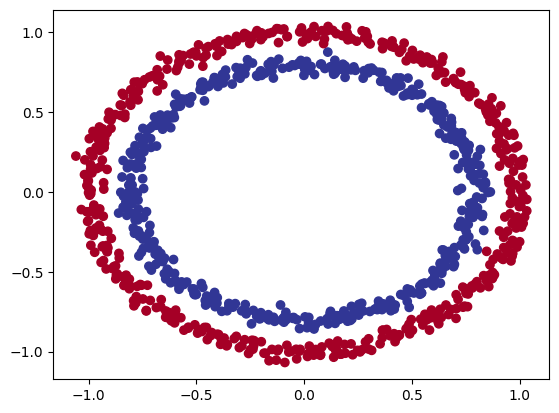

In [5]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)
plt.show()

In [6]:
# plt.plot(X[y==0, 0], X[y==0, 1], "r.")
# plt.plot(X[y==1, 0], X[y==1, 1], "b.")
# plt.show()

In [7]:
X.shape, y.shape

((1000, 2), (1000,))

In [8]:
torch.__version__

'2.8.0+cu126'

In [9]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
len(X_train), len(X_test)

(800, 200)

In [12]:
# Build model to classify red and blue dots

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device


'cpu'

In [13]:
class CircleModel(nn.Module):
  def __init__(self) :
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=5)
    self.layer_2 = nn.Linear(in_features=5, out_features=1)

  def forward(self,x):
    return self.layer_2(self.layer_1(x))

model_0 = CircleModel().to(device)
model_0

CircleModel(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [14]:
# Using nn.sequential

model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [15]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.2472,  0.4606],
                      [ 0.2192, -0.5136],
                      [ 0.6665, -0.5846],
                      [ 0.6981,  0.6292],
                      [ 0.6216, -0.0732]])),
             ('0.bias', tensor([ 0.1951, -0.4861,  0.3471,  0.2236,  0.1532])),
             ('1.weight',
              tensor([[ 0.2582,  0.3470,  0.3141, -0.4075, -0.0763]])),
             ('1.bias', tensor([0.4067]))])

In [16]:

# Make predictions with the model
with torch.inference_mode():
  untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(y_test)}, Shape: {y_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 test labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200])

First 10 predictions:
tensor([[-0.0010],
        [-0.1810],
        [ 0.5275],
        [-0.1510],
        [ 0.6175],
        [ 0.5069],
        [-0.0713],
        [ 0.0901],
        [ 0.5229],
        [-0.1921]])

First 10 test labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [17]:
loss_fn = nn.BCEWithLogitsLoss()
# Can use BCELoss but this has in built nn.sigmoid layer
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)


In [18]:
# Calculate accuracy
def accuracy_fn(y_true,y_pred):
  correct = torch.eq(y_true,y_pred).sum().item()
  acc = (correct/len(y_pred))*100
  return acc

##  Going from raw model outputs to predicted labels
### **(logits -> prediction probabilities -> prediction labels)**

In [19]:
model_0.eval()
with torch.inference_mode():
  y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.0010],
        [-0.1810],
        [ 0.5275],
        [-0.1510],
        [ 0.6175]])

In [20]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [21]:
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4997],
        [0.4549],
        [0.6289],
        [0.4623],
        [0.6496]])

In [22]:
# Find the predicted labels (round the prediction probabilities)
y_preds = torch.round(y_pred_probs)

# In full
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

# Check for equality
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# Get rid of extra dimension
y_preds.squeeze()

tensor([True, True, True, True, True])


tensor([0., 0., 1., 0., 1.])

## Building Traing and Testing

In [23]:
torch.manual_seed(42)

epochs = 100

for epoch in range(epochs) :
  model_0.train()
  y_logits = model_0(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  # loss = loss_fn(torch.sigmoid(y_logits)) -> BCELoss expects prediction probs as i/p
  loss = loss_fn(y_logits, y_train)   # BCElogitsloss expects logits as i/p
  acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  ### Testing
  model_0.eval()
  with torch.inference_mode():
      test_logits = model_0(X_test).squeeze()
      test_pred = torch.round(torch.sigmoid(test_logits))
        # 2. Caculate loss/accuracy
      test_loss = loss_fn(test_logits,
                            y_test)
      test_acc = accuracy_fn(y_true=y_test,
                               y_pred=test_pred)

  if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.72011, Accuracy: 53.12% | Test loss: 0.70242, Test acc: 52.50%
Epoch: 10 | Loss: 0.71068, Accuracy: 52.00% | Test loss: 0.69629, Test acc: 54.50%
Epoch: 20 | Loss: 0.70547, Accuracy: 50.62% | Test loss: 0.69339, Test acc: 54.50%
Epoch: 30 | Loss: 0.70225, Accuracy: 50.38% | Test loss: 0.69194, Test acc: 54.50%
Epoch: 40 | Loss: 0.70007, Accuracy: 50.25% | Test loss: 0.69118, Test acc: 55.00%
Epoch: 50 | Loss: 0.69851, Accuracy: 50.12% | Test loss: 0.69081, Test acc: 54.50%
Epoch: 60 | Loss: 0.69734, Accuracy: 49.75% | Test loss: 0.69067, Test acc: 54.50%
Epoch: 70 | Loss: 0.69644, Accuracy: 49.62% | Test loss: 0.69066, Test acc: 54.50%
Epoch: 80 | Loss: 0.69574, Accuracy: 49.88% | Test loss: 0.69075, Test acc: 54.50%
Epoch: 90 | Loss: 0.69519, Accuracy: 50.12% | Test loss: 0.69089, Test acc: 54.00%


In [24]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

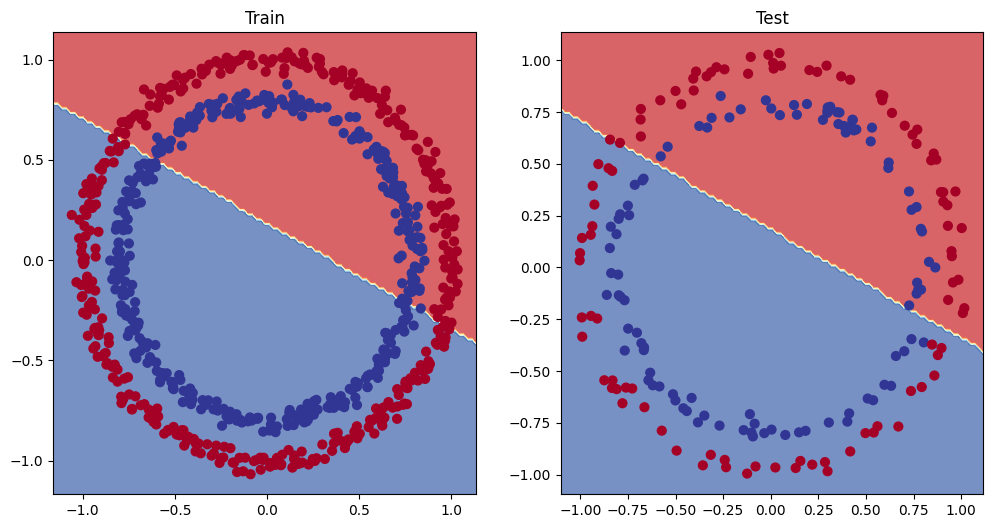

In [25]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

## Improving the model

In [26]:
class CircleModelV1(nn.Module) :
  def __init__(self) :
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)

  def forward(self,X) :
    # z = self.layer_1(X)
    # z = self.layer_2(z)
    # z = self.layer_3(z)
    return self.layer_3(self.layer_2(self.layer_1(X)))

model_1 = CircleModelV1()
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [27]:
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(model_1.parameters(), lr=0.1)


In [28]:
torch.manual_seed(42)

epochs = 1000

for epoch in range(epochs) :
  model_1.train()
  y_logits = model_1(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits, y_train)   # BCElogitsloss expects logits as i
  acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_1.eval()
  with torch.inference_mode() :
    test_logits = model_1(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

    if epoch % 100 == 0 :
      print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69396, Accuracy: 50.88% | Test loss: 0.69261, Test acc: 51.00%
Epoch: 100 | Loss: 0.69305, Accuracy: 50.38% | Test loss: 0.69379, Test acc: 48.00%
Epoch: 200 | Loss: 0.69299, Accuracy: 51.12% | Test loss: 0.69437, Test acc: 46.00%
Epoch: 300 | Loss: 0.69298, Accuracy: 51.62% | Test loss: 0.69458, Test acc: 45.00%
Epoch: 400 | Loss: 0.69298, Accuracy: 51.12% | Test loss: 0.69465, Test acc: 46.00%
Epoch: 500 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69467, Test acc: 46.00%
Epoch: 600 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 700 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 800 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 900 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%


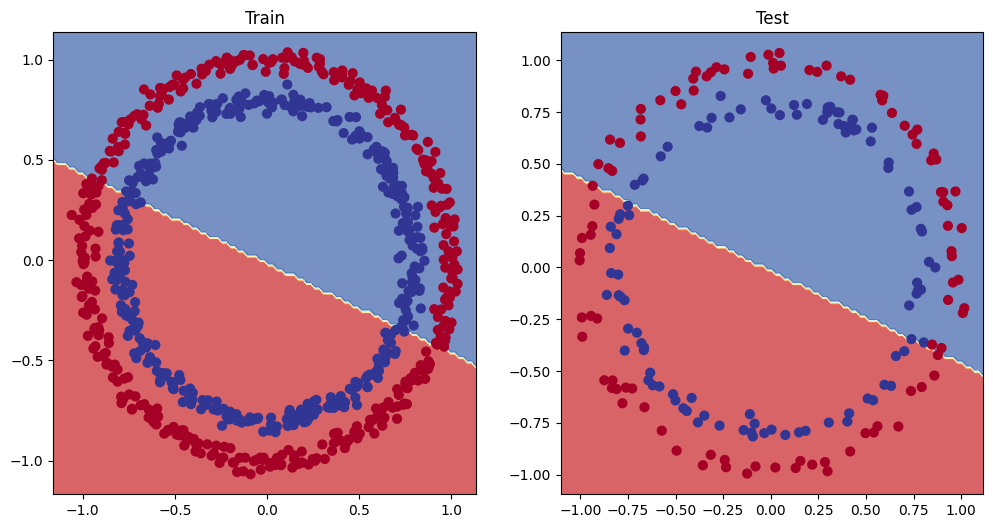

In [29]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

### Checking the model with smaller datset
To CHECK is is leanring or not

In [30]:
# Create some data
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

# Create data
X_regression = torch.arange(start, end, step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias # linear regression formula

# Check the data
print(len(X_regression))
X_regression[:5], y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [31]:
# Create train and test splits
train_split = int(0.8 * len(X_regression)) # 80% of data used for training set
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]

# Check the lengths of each split
print(len(X_train_regression),
    len(y_train_regression),
    len(X_test_regression),
    len(y_test_regression))

80 80 20 20


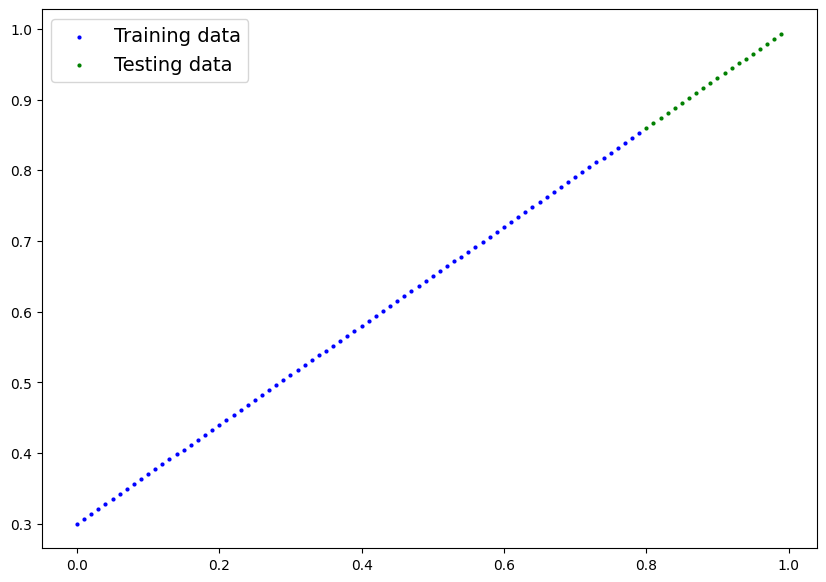

In [32]:
plot_predictions(train_data=X_train_regression,
    train_labels=y_train_regression,
    test_data=X_test_regression,
    test_labels=y_test_regression
);

In [33]:
# Same architecture as model_1
model_2 = nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1)
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [34]:
loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(model_2.parameters(), lr=0.1)

In [35]:
# Train the model
torch.manual_seed(42)


epochs = 1000

for epoch in range(epochs):

    y_pred = model_2(X_train_regression)

    loss = loss_fn(y_pred, y_train_regression)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    ### Testing
    model_2.eval()
    with torch.inference_mode():

      test_pred = model_2(X_test_regression)

      test_loss = loss_fn(test_pred, y_test_regression)

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Train loss: {loss:.5f}, Test loss: {test_loss:.5f}")

Epoch: 0 | Train loss: 0.75986, Test loss: 0.54143
Epoch: 100 | Train loss: 0.09309, Test loss: 0.02901
Epoch: 200 | Train loss: 0.07376, Test loss: 0.02850
Epoch: 300 | Train loss: 0.06745, Test loss: 0.00615
Epoch: 400 | Train loss: 0.06107, Test loss: 0.02004
Epoch: 500 | Train loss: 0.05698, Test loss: 0.01061
Epoch: 600 | Train loss: 0.04857, Test loss: 0.01326
Epoch: 700 | Train loss: 0.06109, Test loss: 0.02127
Epoch: 800 | Train loss: 0.05600, Test loss: 0.01425
Epoch: 900 | Train loss: 0.05571, Test loss: 0.00603


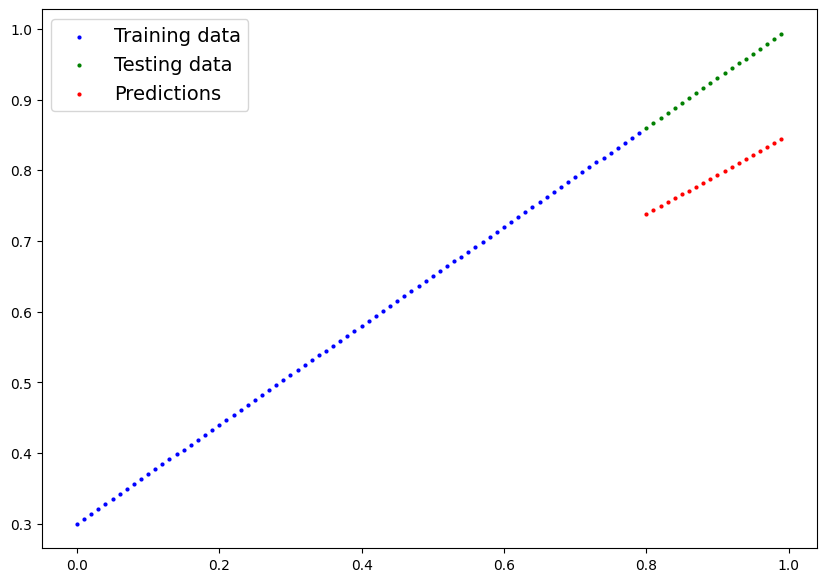

In [36]:
model_2.eval()

# Make predictions
with torch.inference_mode():
    y_preds = model_2(X_test_regression)

plot_predictions(train_data=X_train_regression,
                 train_labels=y_train_regression,
                 test_data=X_test_regression,
                 test_labels=y_test_regression,
                 predictions=y_preds);

## Non-Linearity


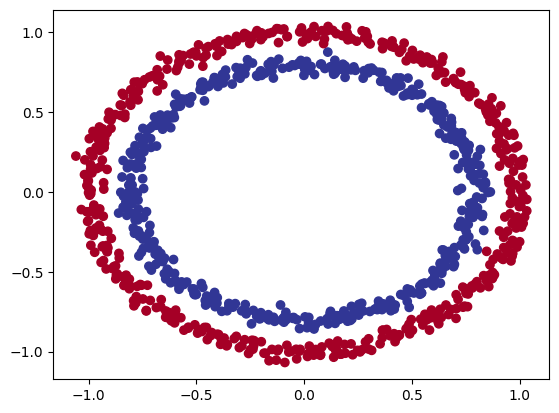

In [37]:
from sklearn.datasets import make_circles

n_samples = 1000

X,y = make_circles(n_samples, noise=0.03, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu);

In [38]:
from sklearn.model_selection import train_test_split

X= torch.from_numpy(X).type(torch.float)
y= torch.from_numpy(y).type(torch.float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

len(X_train), len(X_test)

(800, 200)

In [39]:
# Build model with non linear activation functions...

class CircleModelV2(nn.Module) :
  def __init__(self) :
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)
    self.relu = nn.ReLU()

  def forward(self, X) :
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(X)))))

model_3 = CircleModelV2()
model_3

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [40]:
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(model_3.parameters(), lr=0.01)

In [41]:
epochs = 1000

for epoch in range(epochs) :
    y_logits = model_3(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train,
                      y_pred=y_pred)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    ### Testing
    model_3.eval()
    with torch.inference_mode():

      test_logits = model_3(X_test).squeeze()
      test_pred = torch.round(torch.sigmoid(test_logits))

      test_loss = loss_fn(test_logits, y_test)
      test_acc = accuracy_fn(y_true=y_test,
                             y_pred=test_pred)

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69295, Accuracy: 50.00% | Test Loss: 0.69203, Test Accuracy: 55.50%
Epoch: 100 | Loss: 0.17334, Accuracy: 99.62% | Test Loss: 0.20684, Test Accuracy: 99.00%
Epoch: 200 | Loss: 0.01503, Accuracy: 100.00% | Test Loss: 0.02743, Test Accuracy: 100.00%
Epoch: 300 | Loss: 0.00581, Accuracy: 100.00% | Test Loss: 0.01481, Test Accuracy: 100.00%
Epoch: 400 | Loss: 0.00317, Accuracy: 100.00% | Test Loss: 0.01065, Test Accuracy: 100.00%
Epoch: 500 | Loss: 0.00200, Accuracy: 100.00% | Test Loss: 0.00874, Test Accuracy: 100.00%
Epoch: 600 | Loss: 0.00138, Accuracy: 100.00% | Test Loss: 0.00754, Test Accuracy: 100.00%
Epoch: 700 | Loss: 0.00101, Accuracy: 100.00% | Test Loss: 0.00677, Test Accuracy: 100.00%
Epoch: 800 | Loss: 0.00076, Accuracy: 100.00% | Test Loss: 0.00622, Test Accuracy: 100.00%
Epoch: 900 | Loss: 0.00060, Accuracy: 100.00% | Test Loss: 0.00579, Test Accuracy: 100.00%


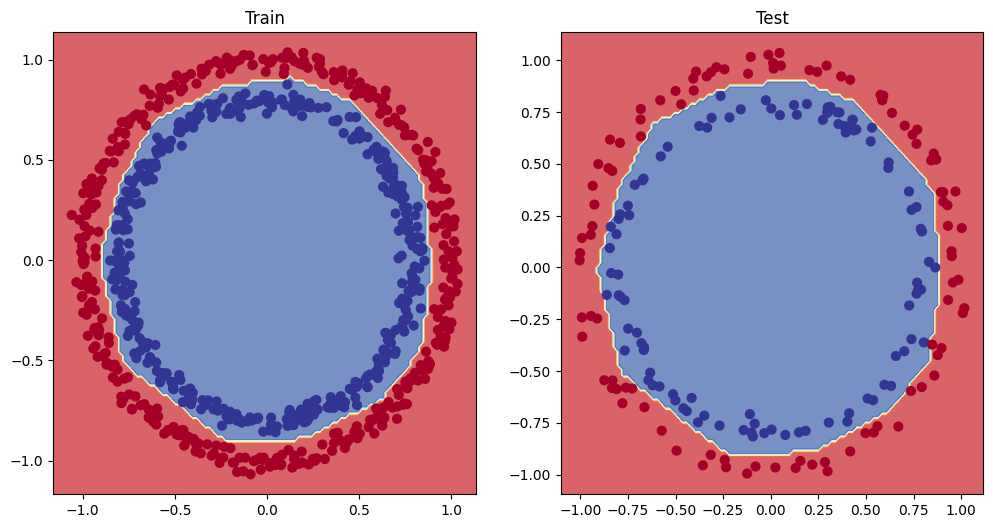

In [42]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_3, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test)

# Putting All Together
A->Z

In [43]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Hyperparameters for further tuning
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

X_blob, y_blob = make_blobs(n_samples = 1000,
                            n_features = NUM_FEATURES,
                            centers = NUM_CLASSES,
                            cluster_std = 1.5,
                            random_state= RANDOM_SEED)

X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.float)

X_train, X_test, y_train, y_test = train_test_split(X_blob,y_blob,
                                                    test_size= 0.2,
                                                    random_state = RANDOM_SEED)

len(X_train), len(X_test)

(800, 200)

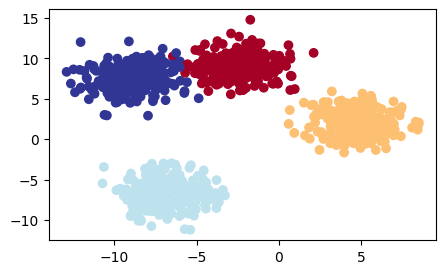

In [44]:
plt.figure(figsize=(5,3))

plt.scatter(X_blob[:,0], X_blob[:,1], c=y_blob, cmap=plt.cm.RdYlBu);

In [45]:
# IF for gpu : device = 'cuda ...


In [46]:
## Model

class BlobModel(nn.Module):
  def __init__(self, input_features, output_features, hidden_units):
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features=input_features,out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,out_features=output_features)
    )

  def forward(self,x):
    return self.linear_layer_stack(x)

model_4 = BlobModel(input_features=2, output_features=4, hidden_units=8)

model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [47]:
torch.unique(y_train)

tensor([0., 1., 2., 3.])

In [48]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(model_4.parameters(), lr=0.1)


#### Logits -> Pred probs -> Pred labels

In [49]:
# predictions Using logits
model_4.eval()
with torch.inference_mode() :
  y_logits = model_4(X_test)
y_logits[:10]

tensor([[-0.4603,  0.1242, -0.1447,  0.2262],
        [-0.3816,  0.7560,  1.3547,  1.3346],
        [-0.4090,  0.1508, -0.2864, -0.2967],
        [-0.3858, -0.0221, -0.1996,  0.0551],
        [-0.3900,  0.3935,  0.9896,  1.2713],
        [-0.3793,  0.9113,  1.6622,  1.5931],
        [-0.3756,  0.0158, -0.2429, -0.1414],
        [-0.3654,  0.4080,  1.0557,  1.2904],
        [-0.4099,  0.2396, -0.3249, -0.4981],
        [-0.3677,  0.3699,  1.0126,  1.2804]])

In [50]:
# pred_probs
y_pred_probs = torch.softmax(y_logits, dim=1)
y_pred_probs[:5], y_logits[:5]

(tensor([[0.1626, 0.2916, 0.2229, 0.3230],
         [0.0651, 0.2031, 0.3696, 0.3622],
         [0.2000, 0.3501, 0.2261, 0.2238],
         [0.1924, 0.2768, 0.2318, 0.2990],
         [0.0805, 0.1761, 0.3197, 0.4237]]),
 tensor([[-0.4603,  0.1242, -0.1447,  0.2262],
         [-0.3816,  0.7560,  1.3547,  1.3346],
         [-0.4090,  0.1508, -0.2864, -0.2967],
         [-0.3858, -0.0221, -0.1996,  0.0551],
         [-0.3900,  0.3935,  0.9896,  1.2713]]))

In [51]:
#y_pred_labels
torch.argmax(y_pred_probs, dim=1)[:5]

tensor([3, 2, 1, 3, 3])

### Training and testing

In [52]:
# Training and testing loop

epochs = 200

for epoch in range(epochs) :
  model_4.train()

  y_logits = model_4(X_train)
  y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

  loss = loss_fn(y_logits, y_train.type(torch.long))
  acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_4.eval()
  with torch.inference_mode() :
    test_logits = model_4(X_test)
    test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
    test_loss = loss_fn(test_logits, y_test.type(torch.long))
    test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

  if epoch % 20 == 0 :
    print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 1.58554, Accuracy: 5.25% | Test loss: 1.29624, Test acc: 29.00%
Epoch: 20 | Loss: 0.83246, Accuracy: 70.75% | Test loss: 0.79901, Test acc: 68.50%
Epoch: 40 | Loss: 0.26207, Accuracy: 96.25% | Test loss: 0.21868, Test acc: 96.50%
Epoch: 60 | Loss: 0.07516, Accuracy: 99.25% | Test loss: 0.06432, Test acc: 99.50%
Epoch: 80 | Loss: 0.04825, Accuracy: 99.25% | Test loss: 0.03923, Test acc: 99.50%
Epoch: 100 | Loss: 0.03886, Accuracy: 99.12% | Test loss: 0.02985, Test acc: 99.50%
Epoch: 120 | Loss: 0.03435, Accuracy: 99.12% | Test loss: 0.02510, Test acc: 99.50%
Epoch: 140 | Loss: 0.03177, Accuracy: 99.12% | Test loss: 0.02226, Test acc: 99.50%
Epoch: 160 | Loss: 0.03013, Accuracy: 99.12% | Test loss: 0.02039, Test acc: 99.50%
Epoch: 180 | Loss: 0.02902, Accuracy: 99.12% | Test loss: 0.01906, Test acc: 99.50%


In [55]:
model_4.eval()
with torch.inference_mode():
  y_logits = model_4(X_test)
  y_pred_probs = torch.softmax(y_logits, dim=1)
  y_pred_probs[:5]

In [56]:
y_preds = torch.argmax(y_pred_probs, dim=1)
y_preds[:5]

tensor([1, 3, 2, 1, 0])

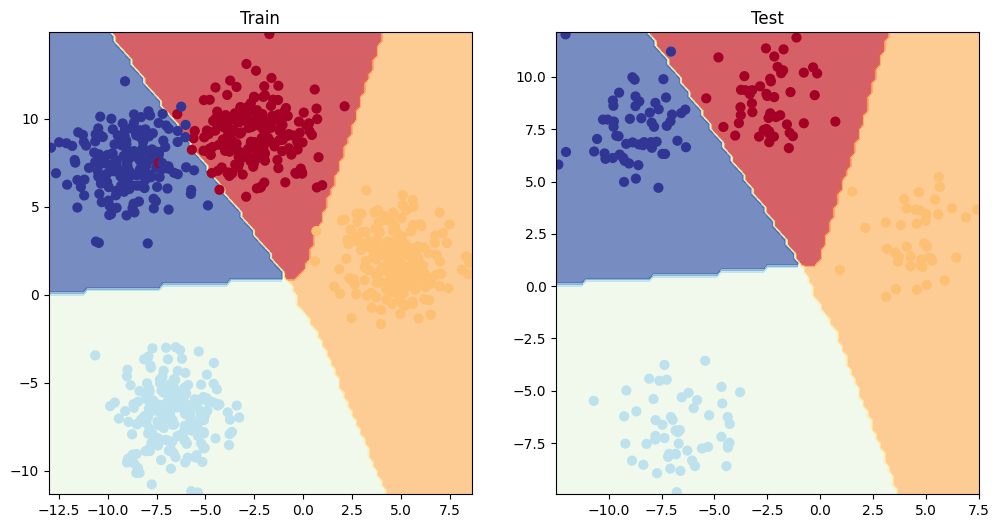

In [59]:
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_4, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_4, X_test, y_test)


In [64]:
# METRICS
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 15.1 MB/s eta 0:00:00


In [65]:
from torchmetrics import Accuracy

torchmetrics_acc = Accuracy(task="multiclass", num_classes=4)
torchmetrics_acc(y_preds, y_test)

tensor(0.9950)

In [60]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_preds)
cm

array([[49,  0,  0,  0],
       [ 0, 41,  0,  0],
       [ 0,  0, 53,  0],
       [ 1,  0,  0, 56]])

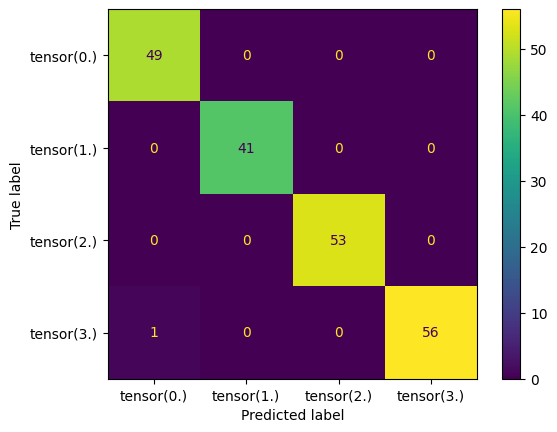

In [62]:
from sklearn.metrics import ConfusionMatrixDisplay

cm_plot = ConfusionMatrixDisplay(cm, display_labels=torch.unique(y_blob))
cm_plot.plot()